# Automatically Selecting Reference Points

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import xarray as xr
from pathlib import Path
import rasterio
from scipy.stats import linregress

from faninsar import NSBAS, query, datasets, samplers

In [2]:
out_dir = Path("/Volumes/Data/GeoData/YNG/Sentinel1/Hyp3/descending_roi/result/ARPs/aux_data")

tmp_file = Path("/Volumes/Data/GeoData/YNG/Temperature/ERA5/result/calibrated/spatialT_cal.nc")
cum_file = Path("/Volumes/Data/GeoData/YNG/Sentinel1/Hyp3/descending_roi/result/cumulative_deformation.tif")
pf_pt = query.Points([98.84111965, 38.79726347],crs=4326)


In [3]:
pf_pt.to_file(out_dir / "pf_pt.geojson")

In [3]:
## load cum deformation time series 
with rasterio.open(cum_file) as ds:
    dates = pd.to_datetime(ds.descriptions)

ds_cum = datasets.RasterDataset(paths=[cum_file], verbose=False)
sample_pt = ds_cum[pf_pt]
pf_dfm = sample_pt.points.data[0]

## load temperature time series
ds_tmp = xr.open_dataset(tmp_file)
df_tmp = ds_tmp.sel(lat=pf_pt.y[0], lon=pf_pt.y[0], method="nearest")["surface air temperature"].to_series()
ds_tmp.close()

In [5]:
ftc = NSBAS.FreezeThawCycle(df_tmp.index, df_tmp.values, ER=1.4, day_duration=20)
model_ftc = NSBAS.FreezeThawCycleModelWithVelocity(ftc, dates)

In [6]:
model_ftc.G_br.shape, pf_dfm.shape

((183, 4), (183,))

In [7]:
params = np.linalg.lstsq(model_ftc.G_br, pf_dfm, rcond=None)[0]

## remove the long term trend
# params[2:] = 0
cum_ftc = model_ftc.G_br @ params

Text(0.5, 1.0, 'Cumulative deformation modelled by stefan-equation-based model')

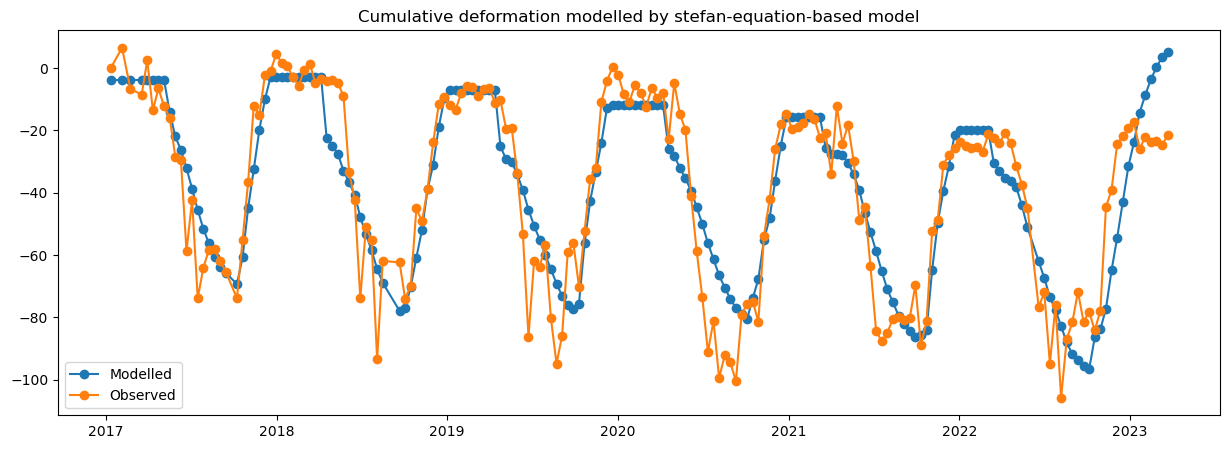

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(dates, cum_ftc, marker='o', label="Modelled")
plt.plot(dates, pf_dfm, marker='o', label="Observed")
plt.legend()
plt.title("Cumulative deformation modelled by stefan-equation-based model")

## calculate the slope of function

In [9]:
slope_file = out_dir / "slope.tif"
r_file = out_dir / "r.tif"
p_file = out_dir / "p.tif"
se_file = out_dir / "se.tif"

In [10]:
def get_linear_slope(cum_dfm, cum_ftc, dates, slope_only=False):
    """Compute the slope of linear function between cum_dfm and cum_ftc
    
    Parameters
    ----------
    cum_dfm : np.ndarray (n_date, n_pixel)
        The cumulative deformation time series
    cum_ftc : np.ndarray (n_date, )
        The modelled freeze-thaw cycle time series of selected pixel
    dates : pd.DatetimeIndex (n_date, )
        The dates of the time series
    slope_only : bool (default: False)
        return the [slope, intercept, r, p, se] if False, otherwise return the 
        slope only. It will be faster if slope_only is True as parallel computing
        is possible.
    """
    model_ls = NSBAS.LinearModel(dates)
    
    # detrnd the data
    ## avoid computing the slope for the masked data
    m = ~np.all(cum_dfm.mask, axis=0)
    params = np.linalg.lstsq(model_ls.G_br, cum_dfm[:,m].data, rcond=None)[0]
    cum_data_detrend = np.full_like(cum_dfm, np.nan)
    cum_data_detrend[:,m] = cum_dfm[:,m] - np.dot(model_ls.G_br, params)
    
    # compute the slope of linear function
    x = cum_ftc
    y = cum_data_detrend
    X = np.array([x, np.ones_like(cum_ftc)]).T
    
    if slope_only:
        params = np.linalg.lstsq(X, y, rcond=None)[0]
        slope = params[0]
        return slope
    
    results = []
    for i in tqdm(range(y.shape[1]), desc="Computing linear slope", unit="pixel"):
        y_i = y[:, i]
        if np.all(np.isnan(y_i)):
            result = np.full((5), np.nan)
        else:
            slope, intercept, r, p, se = linregress(x, y_i)
            result = [slope, intercept, r, p, se]
        results.append(result)
    return np.array(results)

   

In [11]:
sampler = samplers.RowSampler(ds_cum, row_num=20)

for bbox in tqdm(sampler, desc="Processing Patches", unit="patch"):
    with rasterio.open(cum_file) as ds:
        win = ds.window(*bbox)
        cum_data = ds.read(window=win, masked=True)

    n_date, n_row, n_col = cum_data.shape
    cum_data = cum_data.reshape(n_date, n_row*n_col)
    
    # slope = get_linear_slope(cum_data, cum_ftc, dates, slope_only=True).reshape(n_row, n_col)
    
    ### derive slope, r, p, se
    slope_result = get_linear_slope(cum_data, cum_ftc, dates)
    slope = slope_result[:, 0].reshape(n_row, n_col)
    r = slope_result[:, 2].reshape(n_row, n_col)
    p = slope_result[:, 3].reshape(n_row, n_col)
    se = slope_result[:, 4].reshape(n_row, n_col)

    # save the results
    ds_cum.array2tiff(slope, slope_file, bbox=bbox)
    ds_cum.array2tiff(r, r_file, bbox=bbox)
    ds_cum.array2tiff(p, p_file, bbox=bbox)
    ds_cum.array2tiff(se, se_file, bbox=bbox)

Processing Patches: 100%|██████████| 20/20 [04:08<00:00, 12.44s/patch]


## calculate the TPI of DEM

In [12]:
dem = Path("/Volumes/Data/GeoData/YNG/Sentinel1/Hyp3/descending_roi/input_dem.tif")

In [13]:
ds_dem = datasets.RasterDataset(paths=[dem], verbose=False, roi=ds_cum.roi, fill_nodata=True)

In [14]:
dem_val= ds_dem[ds_dem.roi].boxes.data.squeeze()

In [15]:
profile = ds_cum.get_profile()
lat, lon = profile.to_latlon()

```bash
conda install -c conda-forge xarray-spatial
```

In [18]:
from xrspatial import convolution
from xrspatial import focal

da_dem = xr.DataArray(
    dem_val,  
    dims=['lat', 'lon'],
    coords={'lat': lat, 'lon': lon}
)
 
# calculate TPI_sd from dem
kernel = convolution.annulus_kernel(1, 1, 25, 1)
TPI_sd = ((da_dem - focal.apply(da_dem, kernel=kernel))
            / focal.apply(da_dem, kernel=kernel, func=focal._calc_std)).values

ds_cum.array2tiff(TPI_sd, out_dir / "TPI_sd.tif")

## parse mean_coherence

In [3]:
home_dir = Path("/Volumes/Data/GeoData/YNG/Sentinel1/Hyp3/descending_roi")

ds_hyp3 = datasets.HyP3S1(home_dir)

In [4]:
pairs_all = ds_hyp3.pairs

con_nearest_winter = (
    pairs_all.where(pairs_all["2017-01":"2023-04"], return_type="mask")
    & (pairs_all.days > 180)
    & (pairs_all.days < 360 + 180)
    & (pairs_all.primary.month.map(lambda x: x in [1, 2, 3]))
    # & (pairs_all.secondary.month.map(lambda x: x in [1, 2, 3]))
)

# loops with 5 acquisitions
pairs_idx = (pairs_all.days < 12 * 3 + 1) & (
    pairs_all.where(pairs_all["2017-01":"2023-04"], return_type="mask")
) | con_nearest_winter

pairs = pairs_all[pairs_idx]


## Calculate the mean coherence


In [ ]:
coh_mean = ds_hyp3.coh_dataset.get_mean_coh(pairs=pairs)
ds_hyp3.array2tiff(coh_mean, out_dir / "mean_coh.tif")

100%|██████████| 786/786 [01:15<00:00, 10.40it/s]


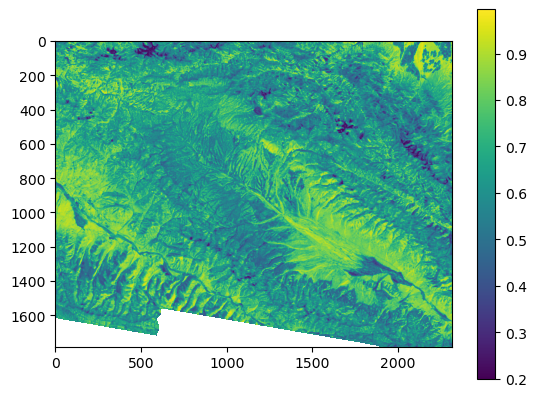

In [7]:
plt.imshow(coh_mean)
plt.colorbar()

In [8]:
ds_hyp3.array2tiff(coh_mean, out_dir / "mean_coh.tif")

## parse nan count

In [5]:
nan_count = ds_hyp3.get_nan_count(pairs)
nan_file = out_dir / "nan_count.tif"

ValueError: cannot select an axis to squeeze out which has size not equal to one

In [ ]:
ds_hyp3._file_query_bbox(roi, files[0]).squeeze(0).mask).astype(int)

HyP3S1 Dataset
    bbox: BoundingBox(left=443501.82025355106, bottom=4263758.21737383, right=536101.820253551, top=4335118.21737383, crs=EPSG:32647)
    file count: 2750

In [ ]:
ds_hyp3.array2tiff(nan_count.astype(float), nan_file)

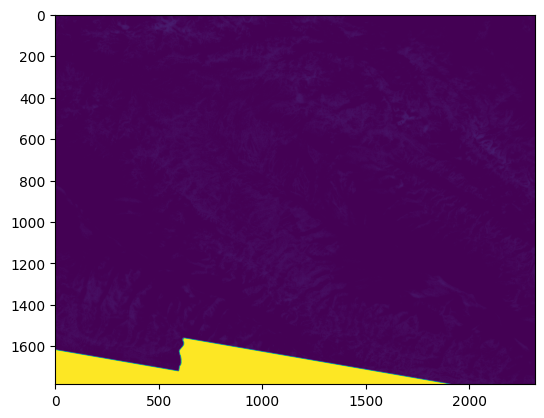

In [ ]:
with rasterio.open(nan_file) as ds:
    arr = ds.read(1,masked=True)
    plt.imshow(arr, cmap="viridis")